<a href="https://colab.research.google.com/github/egiyudasebayang-collab/ML-Linear-Regression-car-price-prediction-/blob/main/notebooks/ML_car_price_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# baca dataset
df = pd.read_csv("car data.csv")

# menampilkan 5 teratas
print("=== 5 Data Teratas ===")
display(df.head())

# cek info tipe data dan missing values
print("\n=== Informasi Dataset ===")
df.info()

=== 5 Data Teratas ===


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0



=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [2]:
# membuat kolom baru
df["Current_Year"] = 2026

# hitung umur mobil
df["Vehicle_Age"] = df["Current_Year"] - df["Year"]

# hapus kolom yang tidak perlu lagi
df.drop(["Year", "Current_Year"], axis=1, inplace=True)

df.head()

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [3]:
# encoding
# drop_first=True , untuk menghindari dummy variabel
df = pd.get_dummies(df, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype=int)

display(df.head())

,Car_Name,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,3.35,5.59,27000,0,12,0,1,0,1
1,sx4,4.75,9.54,43000,0,13,1,0,0,1
2,ciaz,7.25,9.85,6900,0,9,0,1,0,1
3,wagon r,2.85,4.15,5200,0,15,0,1,0,1
4,swift,4.60,6.87,42450,0,12,1,0,0,1


In [4]:
# hapus kolom Car_Name, terlalu banyak kategori unik
df.drop(["Car_Name"], axis=1, inplace=True)

# cek hasil akhir dataset
df.head()


,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1
4,4.60,6.87,42450,0,12,1,0,0,1


In [6]:
# pisah antara fitur dan target
X = df.drop(["Selling_Price"], axis=1)
y = df["Selling_Price"]

print("Ukuran Fitur (X): ", X.shape)
print("Ukuran Target (y) : ", y.shape)

Ukuran Fitur (X):  (301, 8)
Ukuran Target (y) :  (301,)


In [7]:
from sklearn.model_selection import train_test_split

# Membagi data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latihan: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")

Jumlah data latihan: 240
Jumlah data uji: 61


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# latih model dengan data training
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# membuat prediksi dengan data uji
pred = model.predict(X_test)

comparison = pd.DataFrame({"Harga Asli": y_test, "Prediksi Model": pred})
display(comparison.head())

,Harga Asli,Prediksi Model
177,0.35,2.955343
289,10.11,8.178939
228,4.95,6.454273
198,0.15,-1.424175
60,6.95,9.088899


In [11]:
from sklearn import metrics

# Menghitung Metrik Evaluasi
mae = metrics.mean_absolute_error(y_test, pred)
r2 = metrics.r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error (MAE): 1.22
R2 Score: 0.85


In [12]:
import sklearn
import pandas as pd
import seaborn as sns

print(f"pandas=={pd.__version__}")
print(f"scikit-learn=={sklearn.__version__}")
print(f"seaborn=={sns.__version__}")
print(f"numpy=={np.__version__}")

pandas==2.2.2
scikit-learn==1.6.1
seaborn==0.13.2
numpy==2.0.2


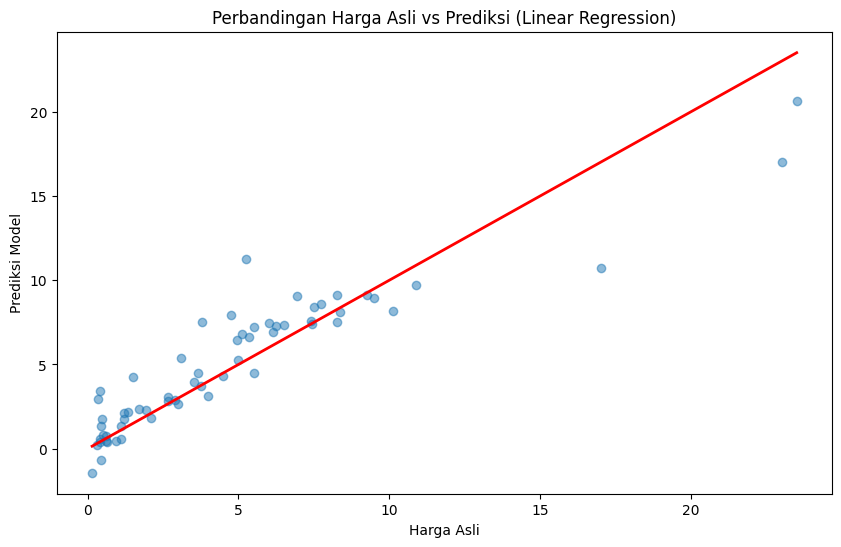

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, pred, alpha=0.5)
plt.xlabel("Harga Asli")
plt.ylabel("Prediksi Model")
plt.title("Perbandingan Harga Asli vs Prediksi (Linear Regression)")
# Tambahkan garis diagonal ideal
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)
plt.show()